# Tesla Sales & Production Analysis

## Objective
This project analyzes Tesla sales and production data to identify trends, understand feature relationships, build predictive machine learning models, and perform time-series forecasting.

### Goals
- Perform exploratory data analysis (EDA)
- Engineer relevant features
- Build and evaluate regression models
- Compare model performance
- Forecast future production trends using ARIMA

## Loading Libraries

In [1]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from statsmodels.tsa.arima.model import ARIMA

print("All Imports are done")


All Imports are done


## Dataset Loading and Inspection

In [2]:
df = pd.read_csv("datasets/week2_dataset_tesla.csv")

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [3]:
df.shape
df.info()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   str    
 3   Model                 2640 non-null   str    
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   str    
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), str(3)
memory usage: 247.6 KB


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

In [4]:
df.duplicated().sum()

np.int64(0)

## Correlation Analysis

A correlation matrix is used to identify linear relationships between numerical variables.

Values close to:
- +1 indicate strong positive correlation
- -1 indicate strong negative correlation
- 0 indicate little or no linear relationship

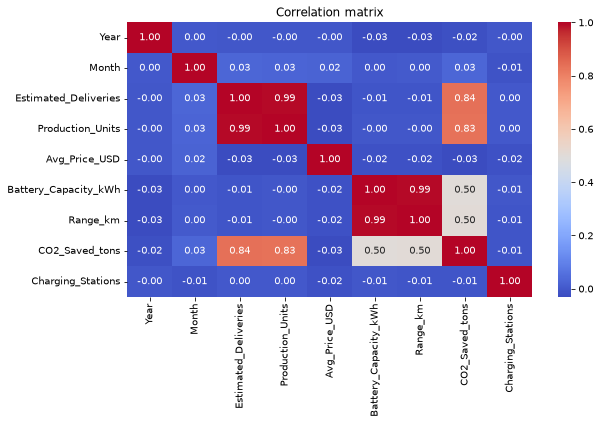

In [5]:
corr = df.corr(numeric_only=True)
plt.figure(figsize=(9, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation matrix')
plt.tight_layout()
plt.show()

## Distribution Analysis

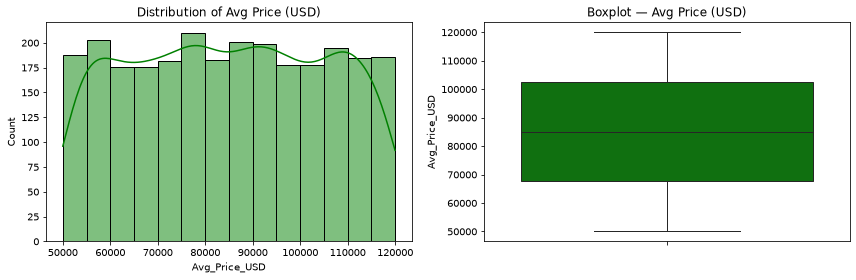

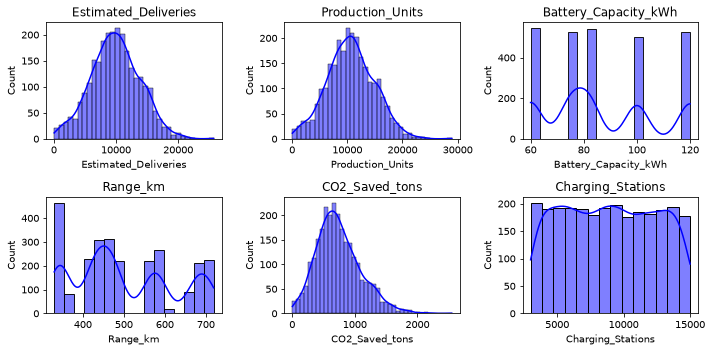

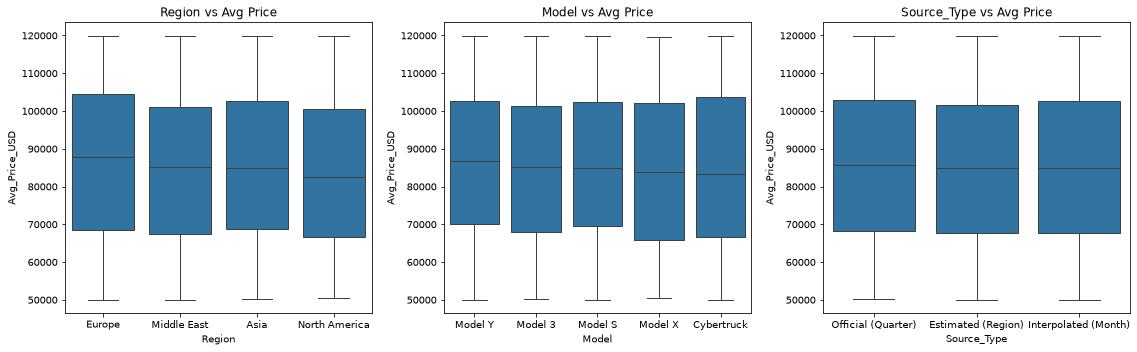

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(df['Avg_Price_USD'], kde=True, color='green', ax=axes[0])
axes[0].set_title('Distribution of Avg Price (USD)')
sns.boxplot(y=df['Avg_Price_USD'], color='green', ax=axes[1])
axes[1].set_title('Boxplot — Avg Price (USD)')
plt.tight_layout()
plt.show()

cols = ['Estimated_Deliveries','Production_Units','Battery_Capacity_kWh','Range_km','CO2_Saved_tons','Charging_Stations']
plt.figure(figsize=(10,5))
for col in cols:
    plt.subplot(2,3,cols.index(col)+1)
    sns.histplot(df[col],kde=True,color='blue')
    plt.title(col)
plt.tight_layout()
plt.show()

cols = ['Region', 'Model', 'Source_Type']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, col in zip(axes, cols):
    order = df.groupby(col)['Avg_Price_USD'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='Avg_Price_USD', order=order, ax=ax)
    ax.set_title(f'{col} vs Avg Price')
plt.tight_layout()
plt.show()

## Time Series Analysis

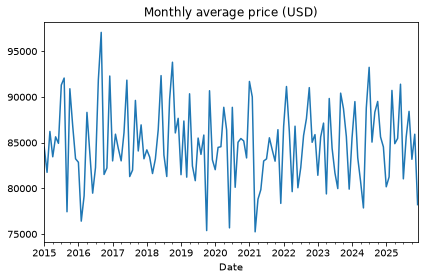

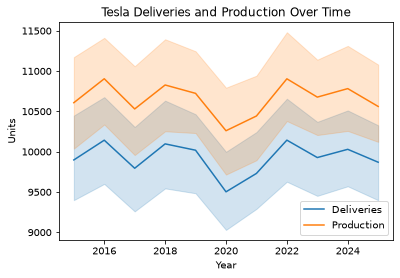

In [7]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
monthly_avg = df.groupby('Date')['Avg_Price_USD'].mean()
monthly_avg.plot()
plt.title('Monthly average price (USD)')
plt.tight_layout()
plt.show()

sns.lineplot(x=df['Year'], y=df['Estimated_Deliveries'], label='Deliveries')
sns.lineplot(x=df['Year'], y=df['Production_Units'], label='Production')
plt.title('Tesla Deliveries and Production Over Time')
plt.ylabel('Units')
plt.show()

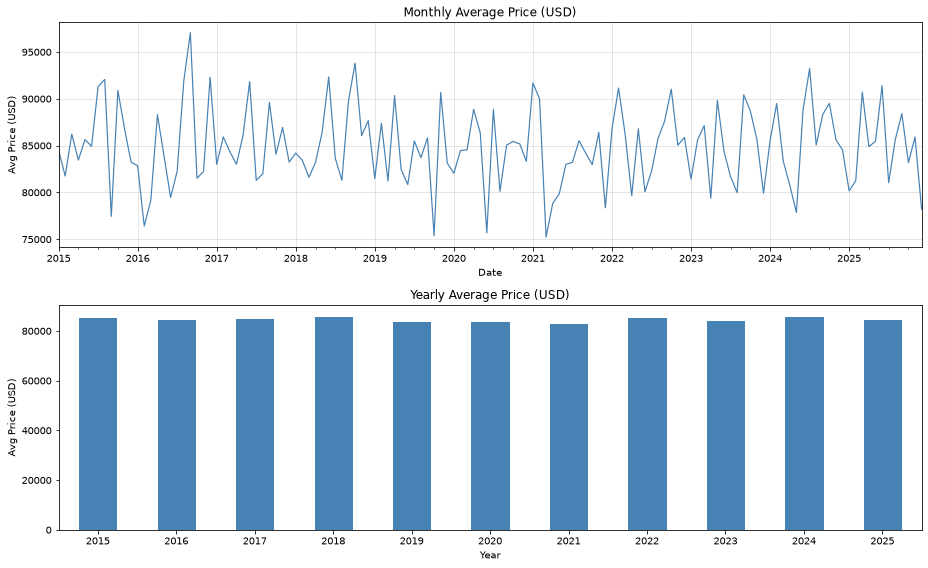

In [8]:
df['Date'] = pd.to_datetime(df[['Year', 'Month']].assign(Day=1))
monthly_avg = df.groupby('Date')['Avg_Price_USD'].mean()
yearly_avg  = df.groupby('Year')['Avg_Price_USD'].mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 8))
monthly_avg.plot(ax=axes[0], color='steelblue', linewidth=1.2)
axes[0].set_title('Monthly Average Price (USD)')
axes[0].set_ylabel('Avg Price (USD)')
axes[0].grid(True, alpha=0.4)
yearly_avg.plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Yearly Average Price (USD)')
axes[1].set_ylabel('Avg Price (USD)')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## Data Preprocessing

In [9]:
df = pd.get_dummies(df,columns=['Region','Model','Source_Type'],drop_first=True,dtype=int)

X = df.drop(['Production_Units', 'Date'], axis=1)
y = df['Production_Units']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")

Train: (2112, 17)  |  Test: (528, 17)


## Regression Modeling

Three regression models are evaluated:

1. Linear Regression
2. Ridge Regression
3. Random Forest Regression

The target variable is:
**Production_Units**

In [10]:
def report(name, y_true, y_pred):
    print(f"{name}")
    print(f"  MAE : {mean_absolute_error(y_true, y_pred):>12,.2f}")
    print(f"  RMSE : {mean_squared_error(y_true, y_pred)**0.5:>12,.2f}")
    print(f"  R²  : {r2_score(y_true, y_pred):>12.4f} \n")

model = LinearRegression()
model.fit(X_train,y_train)
y_pred_lr = model.predict(X_test)
report("Linear Regression", y_test, y_pred_lr)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
y_pred_ridge = ridge.predict(X_test)
report("Ridge Regression", y_test, y_pred_ridge)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
report("Random Forest", y_test, y_pred_rf)

Linear Regression
  MAE :       363.65
  RMSE :       449.74
  R²  :       0.9883 

Ridge Regression
  MAE :       363.64
  RMSE :       449.73
  R²  :       0.9883 

Random Forest
  MAE :       389.97
  RMSE :       485.11
  R²  :       0.9864 



## Model Evaluation

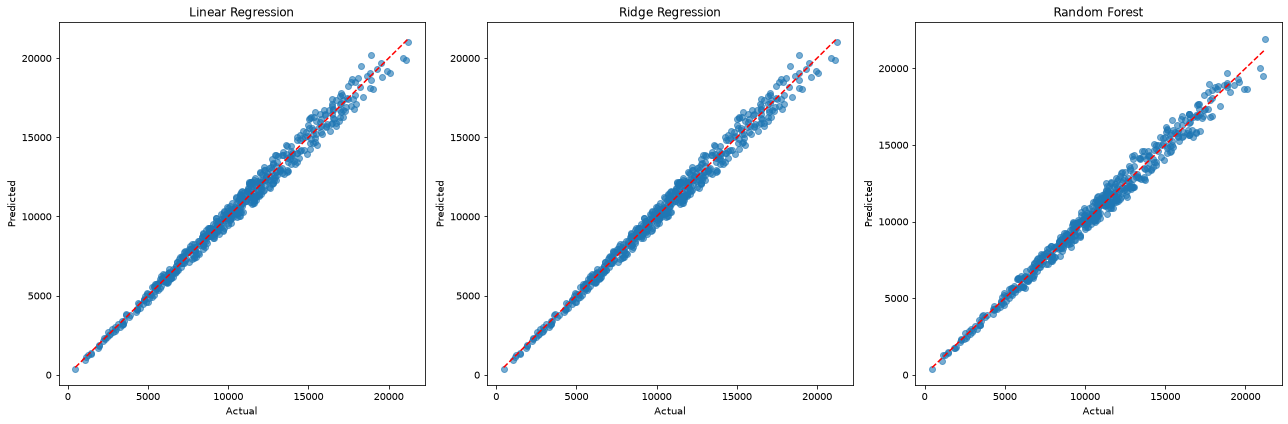

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].scatter(y_test, y_pred_lr, alpha=0.6)
axes[0].plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title("Linear Regression")

axes[1].scatter(y_test, y_pred_ridge, alpha=0.6)
axes[1].plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')
axes[1].set_xlabel('Actual')
axes[1].set_ylabel('Predicted')
axes[1].set_title("Ridge Regression")

axes[2].scatter(y_test, y_pred_rf, alpha=0.6)
axes[2].plot([y_test.min(), y_test.max()],[y_test.min(), y_test.max()],'r--')
axes[2].set_xlabel('Actual')
axes[2].set_ylabel('Predicted')
axes[2].set_title("Random Forest")

plt.tight_layout()
plt.show()

In [12]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge", "Random Forest"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_ridge),
        mean_absolute_error(y_test, y_pred_rf)
    ],
    "RMSE": [
        mean_squared_error(y_test, y_pred_lr)**0.5,
        mean_squared_error(y_test, y_pred_ridge)**0.5,
        mean_squared_error(y_test, y_pred_rf)**0.5
    ],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_ridge),
        r2_score(y_test, y_pred_rf)
    ]
})

print(results)

               Model         MAE        RMSE        R2
0  Linear Regression  363.648182  449.739577  0.988293
1              Ridge  363.643500  449.732840  0.988294
2      Random Forest  389.969811  485.114286  0.986379


In [13]:
coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coef = coef.sort_values("Coefficient", ascending=False)
print(coef.head(10))

print()

importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

print(importance.head(10))

                             Feature  Coefficient
16    Source_Type_Official (Quarter)    22.267439
15  Source_Type_Interpolated (Month)    16.985498
8                      Region_Europe    15.462438
11                     Model_Model 3     7.161345
10              Region_North America     1.356817
2               Estimated_Deliveries     1.080266
5                           Range_km     0.648079
3                      Avg_Price_USD    -0.000796
7                  Charging_Stations    -0.001556
6                     CO2_Saved_tons    -0.033210

                           Feature  Importance
2             Estimated_Deliveries    0.990922
3                    Avg_Price_USD    0.001760
7                Charging_Stations    0.001450
6                   CO2_Saved_tons    0.001296
5                         Range_km    0.000985
1                            Month    0.000945
0                             Year    0.000909
9               Region_Middle East    0.000218
11                   Model

## Time Series Forecasting

An ARIMA model is used to forecast future production trends.

In [14]:
df['Date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'].astype(str))
ts = ( df.groupby('Date')['Production_Units'].mean().sort_index().asfreq('MS'))

arima = ARIMA(ts, order=(2,1,2))
fit = arima.fit()
forecast = fit.forecast(12)
print(forecast)

2026-01-01    10640.165033
2026-02-01    10662.532366
2026-03-01    10574.794386
2026-04-01    10649.789718
2026-05-01    10578.477664
2026-06-01    10645.401365
2026-07-01    10582.498088
2026-08-01    10641.611510
2026-09-01    10586.058383
2026-10-01    10638.265508
2026-11-01    10589.202838
2026-12-01    10635.310443
Freq: MS, Name: predicted_mean, dtype: float64
